# 02 — Limpeza de Dados
**Projeto: Data Science dos Santos Católicos**

Neste notebook transformamos `saints_raw.csv` (dados brutos) em `saints_clean.csv` (pronto para análise).

**O que faremos:**
1. Inspecionar valores nulos com mapa visual
2. Criar colunas derivadas (século, anos até canonização, flags)
3. Padronizar países e mapear continentes
4. Tratar outliers e inconsistências
5. Inferir gênero e preencher lacunas
6. Salvar `saints_clean.csv`

## Setup

In [1]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
DATA_RAW  = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC = PROJECT_ROOT / 'data' / 'processed'
DATA_EXT  = PROJECT_ROOT / 'data' / 'external'
FIGS      = PROJECT_ROOT / 'outputs' / 'figures'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})
sns.set_theme(style='whitegrid')

df = pd.read_csv(DATA_RAW / 'saints_raw.csv')
print(f'Shape original: {df.shape}')
df.head()

Shape original: (77, 12)


,name,death_year,canonization_year,origin_country,category,religious_order,feast_month,feast_day,gender,patron_topics,canonizing_pope,wikipedia_summary
0,Peter the Apostle,68,1000,Palestine,Martyr,NaN,6.0,29.0,M,"fishermen, papacy",Pre-Congregation,Saint Peter (born Shimon bar Yonah; 1 BC – AD ...
1,Paul the Apostle,67,1000,Turkey,Martyr,NaN,6.0,29.0,M,"missionaries, theologians",Pre-Congregation,Paul (born Saul of Tarsus; c. 5 – c. 64/65 AD)...
2,Stephen,36,1000,Palestine,Martyr,NaN,12.0,26.0,M,"deacons, stonemasons",Pre-Congregation,Stephen or Steven is an English male first nam...
3,Mary Magdalene,63,1000,Palestine,Confessor,NaN,7.0,22.0,F,"penitents, perfumers",Pre-Congregation,Mary Magdalene (sometimes called Mary of Magda...
4,John the Apostle,100,1000,Palestine,Confessor,NaN,12.0,27.0,M,"theologians, booksellers",Pre-Congregation,John the Apostle (Ancient Greek: Ἰωάννης; Lati...


## 1. Mapa de Valores Nulos

In [2]:
# Visão geral dos nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)

print('Nulos por coluna:')
for col, n, p in zip(nulos.index, nulos.values, nulos_pct.values):
    barra = '█' * int(p / 5)
    print(f'  {col:<25} {n:>4}  ({p:>5.1f}%)  {barra}')

Nulos por coluna:
  religious_order             37  ( 48.1%)  █████████
  name                         0  (  0.0%)  
  canonization_year            0  (  0.0%)  
  death_year                   0  (  0.0%)  
  origin_country               0  (  0.0%)  
  category                     0  (  0.0%)  
  feast_month                  0  (  0.0%)  
  feast_day                    0  (  0.0%)  
  gender                       0  (  0.0%)  
  patron_topics                0  (  0.0%)  
  canonizing_pope              0  (  0.0%)  
  wikipedia_summary            0  (  0.0%)  


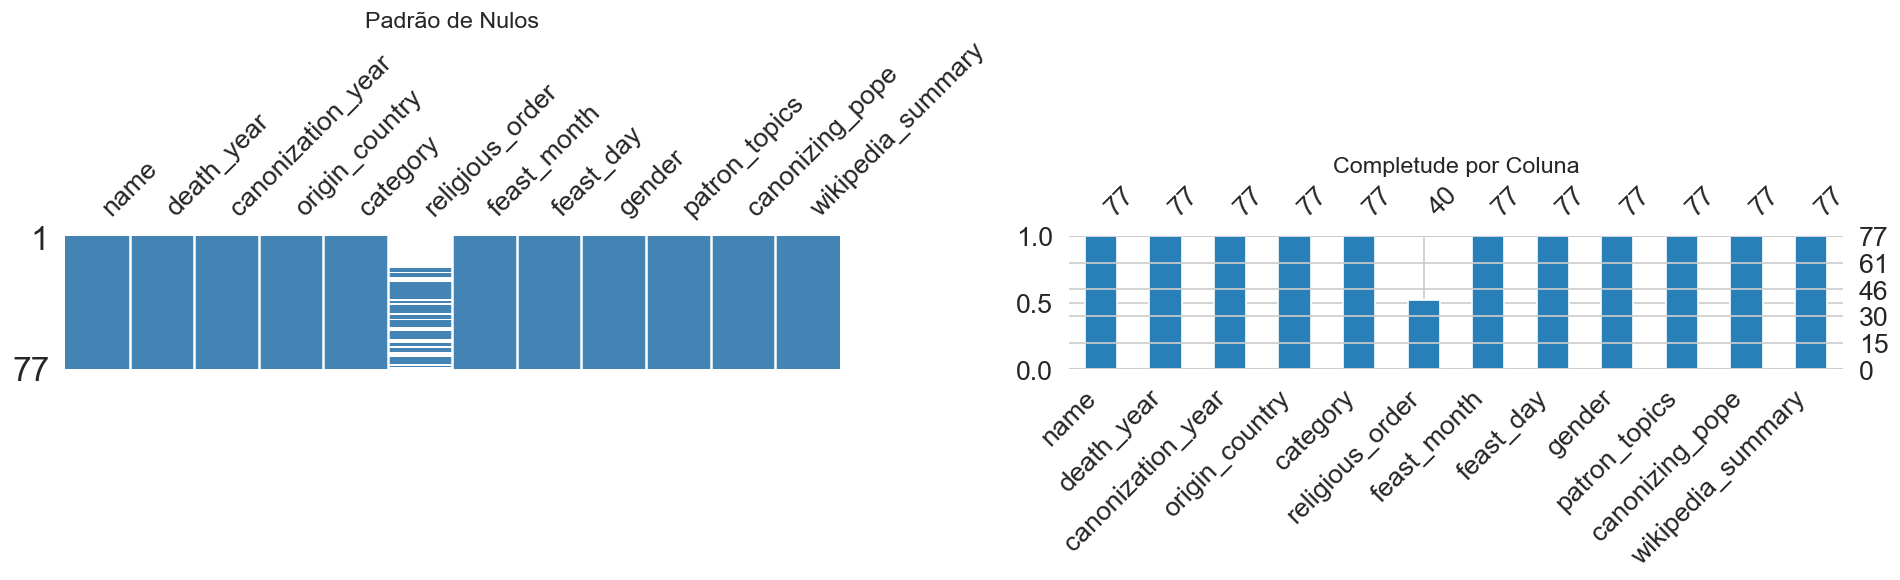

In [3]:
# Mapa visual de nulos (missingno)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(df, ax=axes[0], sparkline=False, color=(0.27, 0.52, 0.71))
axes[0].set_title('Padrão de Nulos', fontsize=14)

msno.bar(df, ax=axes[1], color='#2980B9')
axes[1].set_title('Completude por Coluna', fontsize=14)

plt.tight_layout()
plt.savefig(FIGS / '02_mapa_nulos.png', bbox_inches='tight')
plt.show()

## 2. Colunas Derivadas

In [4]:
# Garantir que anos são numéricos
df['death_year']        = pd.to_numeric(df['death_year'], errors='coerce')
df['canonization_year'] = pd.to_numeric(df['canonization_year'], errors='coerce')

# Anos até canonização
df['years_to_canonization'] = df['canonization_year'] - df['death_year']

# Século de morte (séc. I = ano 1–100, séc. II = 101–200, etc.)
df['century_of_death'] = np.where(
    df['death_year'].notna(),
    ((df['death_year'] - 1) // 100 + 1).astype('Int64'),
    pd.NA
)

print('Novas colunas:')
df[['name', 'death_year', 'canonization_year', 'years_to_canonization', 'century_of_death']].head(10)

Novas colunas:


,name,death_year,canonization_year,years_to_canonization,century_of_death
0,Peter the Apostle,68,1000,932,1
1,Paul the Apostle,67,1000,933,1
2,Stephen,36,1000,964,1
3,Mary Magdalene,63,1000,937,1
4,John the Apostle,100,1000,900,1
5,Ignatius of Antioch,108,1000,892,2
6,Polycarp of Smyrna,155,1000,845,2
7,Justin Martyr,165,1000,835,2
8,Irenaeus of Lyon,202,1000,798,3
9,Perpetua,203,1000,797,3


In [5]:
# Flags booleanas a partir da coluna 'category'
cat_lower = df['category'].fillna('').str.lower()

df['is_martyr']   = cat_lower.str.contains('martyr')
df['is_doctor']   = cat_lower.str.contains('doctor')
df['is_virgin']   = cat_lower.str.contains('virgin')

# Normalizar categoria para 4 valores padronizados
def normalizar_categoria(cat):
    if pd.isna(cat):
        return 'Other'
    c = str(cat).lower()
    if 'martyr' in c:
        return 'Martyr'
    if 'doctor' in c:
        return 'Doctor'
    if 'virgin' in c:
        return 'Virgin'
    if 'confessor' in c or 'bishop' in c or 'pope' in c or 'abbess' in c:
        return 'Confessor'
    return 'Other'

df['category'] = df['category'].apply(normalizar_categoria)

print('Distribuição de categorias:')
print(df['category'].value_counts())

Distribuição de categorias:
category
Confessor    38
Doctor       23
Martyr       16
Name: count, dtype: int64


In [6]:
# Extrair feast_month se não existir ou tiver nulos
def extrair_mes(val):
    if pd.notna(val) and str(val).strip().isdigit():
        return int(val)
    meses = {'january':1,'february':2,'march':3,'april':4,'may':5,'june':6,
             'july':7,'august':8,'september':9,'october':10,'november':11,'december':12}
    texto = str(val).lower()
    for nome, num in meses.items():
        if nome in texto:
            return num
    return np.nan

if 'feast_month' not in df.columns:
    df['feast_month'] = np.nan
df['feast_month'] = df['feast_month'].apply(extrair_mes)

# Contagem de patronatos
if 'patron_topics' not in df.columns:
    df['patron_topics'] = ''
df['num_patron_topics'] = df['patron_topics'].fillna('').apply(
    lambda x: len([p for p in str(x).split(',') if p.strip()]) if x else 0
)

print('feast_month e num_patron_topics criados.')

feast_month e num_patron_topics criados.


## 3. Padronizar Países e Mapear Continentes

In [7]:
# Mapa de correções de nomes de países
pais_correcoes = {
    'Italia': 'Italy', 'España': 'Spain', 'Espanha': 'Spain',
    'França': 'France', 'Alemanha': 'Germany', 'Polônia': 'Poland',
    'UK': 'United Kingdom', 'Great Britain': 'Britain',
    'USA': 'United States', 'U.S.': 'United States',
    'Korean': 'Korea', 'Vietnamese': 'Vietnam',
    'Holy Land': 'Palestine', 'Judea': 'Palestine',
    'Ottoman Empire': 'Turkey', 'Byzantine Empire': 'Turkey',
    'Roman Empire': 'Italy', 'Gaul': 'France',
    'Persia': 'Iran', 'North Africa': 'Algeria',
}

df['origin_country'] = df['origin_country'].replace(pais_correcoes)
df['origin_country'] = df['origin_country'].str.strip().str.title()

print('Países únicos após padronização:', df['origin_country'].nunique())

Países únicos após padronização: 24


In [8]:
# Mapear países → continentes
regioes = pd.read_csv(DATA_EXT / 'world_regions.csv')
mapa_continente = dict(zip(regioes['country'].str.title(), regioes['continent']))

df['continent'] = df['origin_country'].map(mapa_continente).fillna('Unknown')

print('Distribuição por continente:')
print(df['continent'].value_counts())

Distribuição por continente:
continent
Europe           57
Asia             11
Africa            4
North America     3
South America     2
Name: count, dtype: int64


## 4. Tratar Outliers

In [9]:
# Identificar outliers em years_to_canonization
ytc = df['years_to_canonization'].dropna()

print(f'Mínimo:   {ytc.min():.0f} anos')
print(f'Máximo:   {ytc.max():.0f} anos')
print(f'Mediana:  {ytc.median():.0f} anos')
print(f'Média:    {ytc.mean():.0f} anos')
print(f'\nSantos com > 500 anos até canonização: {(ytc > 500).sum()}')

# Flag: canonização muito antiga (pré-formalização do processo)
df['is_ancient_canonization'] = df['canonization_year'] <= 1000

# Valores negativos (erro de dado) → NaN
df.loc[df['years_to_canonization'] < 0, 'years_to_canonization'] = np.nan

print('\nFlagged como canonização antiga:', df['is_ancient_canonization'].sum())

Mínimo:   -153 anos
Máximo:   964 anos
Mediana:  135 anos
Média:    298 anos

Santos com > 500 anos até canonização: 22

Flagged como canonização antiga: 29


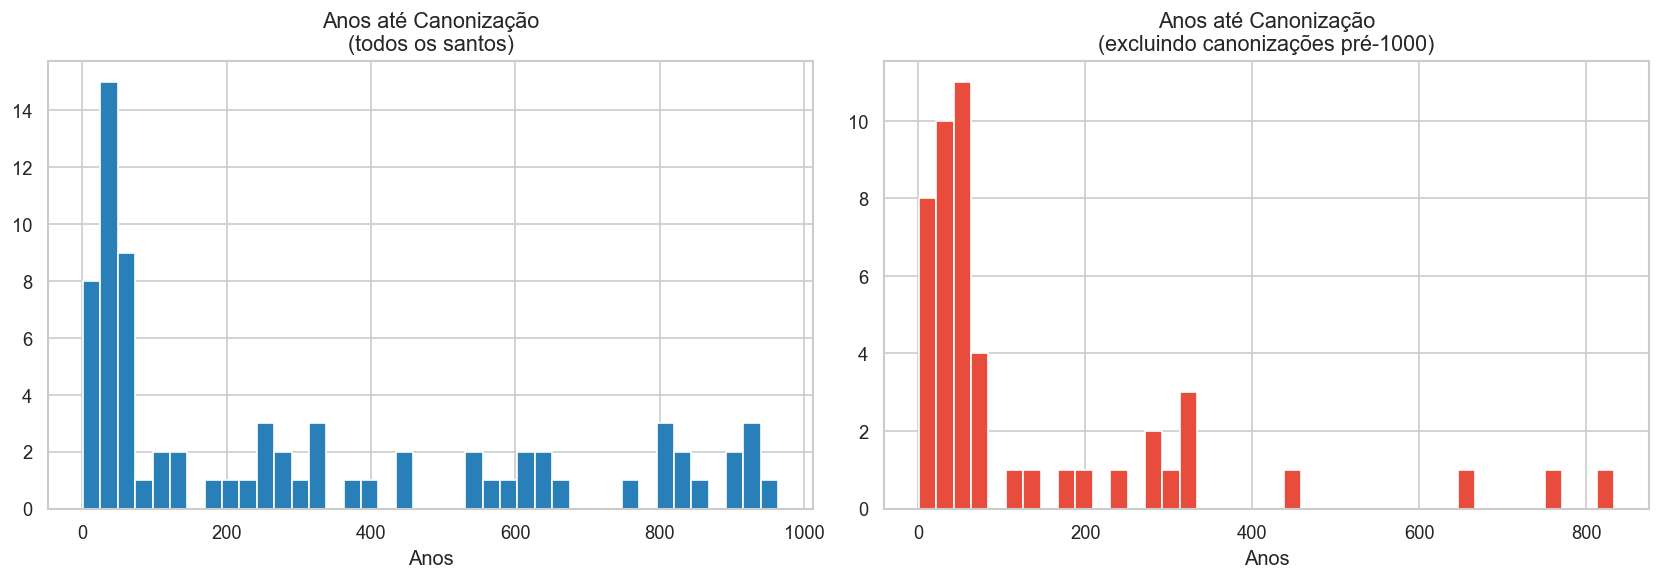

In [10]:
# Visualizar distribuição com e sem outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ytc_todos = df['years_to_canonization'].dropna()
ytc_sem   = df.loc[~df['is_ancient_canonization'], 'years_to_canonization'].dropna()

axes[0].hist(ytc_todos, bins=40, color='#2980B9', edgecolor='white')
axes[0].set_title('Anos até Canonização\n(todos os santos)', fontsize=13)
axes[0].set_xlabel('Anos')

axes[1].hist(ytc_sem, bins=40, color='#E74C3C', edgecolor='white')
axes[1].set_title('Anos até Canonização\n(excluindo canonizações pré-1000)', fontsize=13)
axes[1].set_xlabel('Anos')

plt.tight_layout()
plt.savefig(FIGS / '02_distribuicao_ytc.png', bbox_inches='tight')
plt.show()

## 5. Inferir Gênero

In [11]:
# Nomes femininos conhecidos — lista básica
nomes_femininos = {
    'mary', 'maria', 'teresa', 'therese', 'anne', 'ann', 'catherine',
    'katherine', 'elizabeth', 'margaret', 'agnes', 'monica', 'cecilia',
    'perpetua', 'felicity', 'lucy', 'lucia', 'rose', 'rita', 'faustina',
    'hildegard', 'joan', 'jane', 'louise', 'bernadette', 'gianna',
    'edith', 'kateri', 'clare', 'claire', 'bridget', 'brigid',
    'scholastica', 'genevieve', 'frances', 'flora',
}

def inferir_genero(nome):
    if pd.isna(nome):
        return 'Unknown'
    primeiro = str(nome).split()[0].lower().replace('saint', '').strip()
    return 'F' if primeiro in nomes_femininos else 'M'

# Só preenche onde está vazio
if 'gender' not in df.columns:
    df['gender'] = np.nan

mask_sem_genero = df['gender'].isna() | (df['gender'] == '')
df.loc[mask_sem_genero, 'gender'] = df.loc[mask_sem_genero, 'name'].apply(inferir_genero)

print('Distribuição de gênero:')
print(df['gender'].value_counts())

Distribuição de gênero:
gender
M    60
F    17
Name: count, dtype: int64


## 6. Preencher Ordem Religiosa

In [12]:
if 'religious_order' not in df.columns:
    df['religious_order'] = np.nan

df['religious_order'] = df['religious_order'].fillna('None').str.strip()

print('Ordens religiosas mais comuns:')
print(df['religious_order'].value_counts().head(10))

Ordens religiosas mais comuns:
religious_order
None           37
Benedictine     7
Franciscan      6
Jesuit          6
Dominican       5
Carmelite       4
Salesian        2
Cistercian      1
Oratorian       1
Vincentian      1
Name: count, dtype: int64


## 7. Dataset Final

In [13]:
# Selecionar e ordenar colunas finais
colunas_finais = [
    'name', 'gender',
    'death_year', 'canonization_year', 'years_to_canonization',
    'century_of_death',
    'origin_country', 'continent',
    'category', 'is_martyr', 'is_doctor', 'is_virgin', 'is_ancient_canonization',
    'religious_order',
    'feast_month',
    'patron_topics', 'num_patron_topics',
    'canonizing_pope',
    'wikipedia_summary',
]

# Manter só colunas que existem
colunas_finais = [c for c in colunas_finais if c in df.columns]

df_clean = df[colunas_finais].copy()

# Remover linhas sem nome
df_clean = df_clean.dropna(subset=['name'])
df_clean = df_clean[df_clean['name'].str.strip() != '']

print(f'Shape final: {df_clean.shape}')
print(f'\nNulos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Shape final: (77, 19)

Nulos restantes:
years_to_canonization     2
feast_month              77
dtype: int64


In [14]:
# Salvar
caminho_clean = DATA_PROC / 'saints_clean.csv'
df_clean.to_csv(caminho_clean, index=False)
print(f'Salvo: {caminho_clean}')
print(f'Shape: {df_clean.shape}')
df_clean.describe(include='all').T

Salvo: C:\Users\mateu\OneDrive\Documentos\ESTUDOS I.A\santos_ai_project\data\processed\saints_clean.csv
Shape: (77, 19)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,77,77,Peter the Apostle,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,77,2,M,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
death_year,77.0,NaN,NaN,NaN,1182.935065,652.767758,36.0,547.0,1274.0,1680.0,2005.0
canonization_year,77.0,NaN,NaN,NaN,1481.311688,434.148509,1000.0,1000.0,1610.0,1933.0,2018.0
years_to_canonization,75.0,NaN,NaN,NaN,309.826667,318.327316,1.0,44.5,181.0,575.0,964.0
century_of_death,77.0,18.0,20.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_country,77,24,Italy,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,77,5,Europe,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,77,3,Confessor,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_martyr,77,2,False,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Próximo Passo

Abra o **Notebook 03 — EDA e Gráficos** para criar as 13 visualizações do projeto.